In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

import sys
sys.path.append("../")
from xThreat import xThreat

# Import the data

In [2]:
df_errors = pd.read_csv('../2-calculate-values/bootstrap_errors_normal_xthreat.csv').rename(columns={'sample_size': 'N'})
df_errors['M'] = df_errors['n_x'] * df_errors['n_y']
df_errors['1/sqrt(N)'] = 1/np.sqrt(df_errors['N'])
df_errors['Mlog(M)/sqrt(N)'] = df_errors['M']*np.log(df_errors['M'])*df_errors['1/sqrt(N)']

In [3]:
# Make the norm a dimension independent norm
for col in df_errors.columns.tolist():
    if '1_norm' in col:
        df_errors[col] = df_errors[col]/df_errors['M']
    if ' 2_norm' in col:
        df_errors[col] = df_errors[col]/np.sqrt(df_errors['M'])

# Quick inspection of data

In [4]:
df_errors.head(10)

,n_x,n_y,N,i_bootstrap,random_state,xT_error_1_norm,g_error_1_norm,xG_error_1_norm,prob_shot_error_1_norm,transition_matrix_error_1_norm,...,xT_error_inf_norm,g_error_inf_norm,xG_error_inf_norm,prob_shot_error_inf_norm,transition_matrix_error_inf_norm,transition_matrix_true_inf_norm,transition_matrix_resampled_inf_norm,M,1/sqrt(N),Mlog(M)/sqrt(N)
0,16,12,4000000,0,5176042,0.000561,0.000314,0.007967,0.000580,0.000403,...,0.012561,0.010799,0.500000,0.022223,0.131414,1.0,1.0,192,0.0005,0.50472
1,16,12,4000000,1,5176043,0.000338,0.000166,0.006788,0.000344,0.000401,...,0.012944,0.010130,0.500000,0.008385,0.117864,1.0,1.0,192,0.0005,0.50472
2,16,12,4000000,2,5176044,0.000370,0.000248,0.009014,0.000351,0.000414,...,0.010126,0.011958,0.500000,0.006650,0.132075,1.0,1.0,192,0.0005,0.50472
3,16,12,4000000,3,5176045,0.000605,0.000350,0.005589,0.000430,0.000438,...,0.017236,0.015174,0.157143,0.011811,0.133729,1.0,1.0,192,0.0005,0.50472
4,16,12,4000000,4,5176046,0.000337,0.000259,0.008731,0.000483,0.000433,...,0.015648,0.017580,0.500000,0.012102,0.139206,1.0,1.0,192,0.0005,0.50472
5,16,12,4000000,5,5176047,0.000377,0.000295,0.006898,0.000456,0.000424,...,0.010738,0.013729,0.333333,0.027178,0.135318,1.0,1.0,192,0.0005,0.50472
6,16,12,4000000,6,5176048,0.000508,0.000248,0.007864,0.000433,0.000423,...,0.010959,0.014715,0.300000,0.007857,0.137429,1.0,1.0,192,0.0005,0.50472
7,16,12,4000000,7,5176049,0.000516,0.000312,0.007096,0.000379,0.000428,...,0.010325,0.009123,0.500000,0.012317,0.125164,1.0,1.0,192,0.0005,0.50472
8,16,12,4000000,8,5176050,0.000260,0.000174,0.009133,0.000469,0.000433,...,0.007400,0.008392,0.500000,0.010998,0.122867,1.0,1.0,192,0.0005,0.50472
9,16,12,4000000,9,5176051,0.000322,0.000225,0.011043,0.000332,0.000404,...,0.013202,0.012429,0.500000,0.007486,0.126872,1.0,1.0,192,0.0005,0.50472


In [5]:
df_errors.describe()

,n_x,n_y,N,i_bootstrap,random_state,xT_error_1_norm,g_error_1_norm,xG_error_1_norm,prob_shot_error_1_norm,transition_matrix_error_1_norm,...,xT_error_inf_norm,g_error_inf_norm,xG_error_inf_norm,prob_shot_error_inf_norm,transition_matrix_error_inf_norm,transition_matrix_true_inf_norm,transition_matrix_resampled_inf_norm,M,1/sqrt(N),Mlog(M)/sqrt(N)
count,48000.000000,48000.000000,4.800000e+04,48000.000000,4.800000e+04,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000,...,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000,48000.0,4.800000e+04,48000.000000,48000.000000,48000.000000
mean,42.666667,32.000000,8.675000e+05,499.500000,4.004042e+06,0.003538,0.002476,0.016014,0.004549,0.001197,...,0.366974,0.367379,0.915190,0.382357,1.335572,1.0,1.000000e+00,1552.000000,0.001835,21.544314
std,15.776377,11.832283,1.240817e+06,288.677997,1.698297e+06,0.002297,0.001643,0.005266,0.003040,0.000556,...,0.328582,0.325854,0.180117,0.354952,0.548058,0.0,2.226982e-16,963.470466,0.000873,19.160724
min,16.000000,12.000000,1.000000e+05,0.000000,1.276042e+06,0.000177,0.000099,0.003749,0.000248,0.000294,...,0.002858,0.003053,0.133333,0.004351,0.106011,1.0,1.000000e+00,192.000000,0.000500,0.504720
25%,32.000000,24.000000,1.600000e+05,249.750000,2.917292e+06,0.001605,0.001055,0.012697,0.001980,0.000767,...,0.093645,0.094118,1.000000,0.092308,0.847845,1.0,1.000000e+00,768.000000,0.001164,6.437773
50%,44.000000,33.000000,3.050000e+05,499.500000,3.833542e+06,0.003045,0.002132,0.016920,0.003877,0.001121,...,0.240699,0.246585,1.000000,0.230769,1.543508,1.0,1.000000e+00,1464.000000,0.001843,16.074588
75%,56.000000,42.000000,7.975000e+05,749.250000,4.844791e+06,0.005086,0.003621,0.020023,0.006527,0.001567,...,0.722754,0.716981,1.000000,0.712121,1.811594,1.0,1.000000e+00,2352.000000,0.002512,31.120176
max,64.000000,48.000000,4.000000e+06,999.000000,8.705041e+06,0.011238,0.007951,0.039520,0.014307,0.003382,...,1.000000,1.000000,1.000000,1.000000,1.929577,1.0,1.000000e+00,3072.000000,0.003162,78.008388


## Look at the ratio between maximal error and average error.

findfont: Font family ['DejaVu Sans Display'] not found. Falling back to DejaVu Sans.


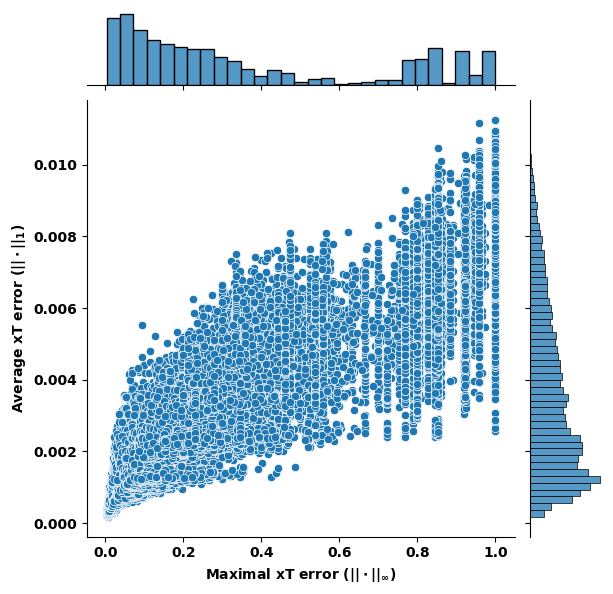

In [6]:
g = sns.jointplot(data=df_errors, x="xT_error_inf_norm", y="xT_error_1_norm")
g.set_axis_labels(r"Maximal xT error ($||\cdot||_\infty$)", r"Average xT error ($||\cdot||_1$)")

In [ ]:
mean_ratio = df_errors['xT_error_1_norm'].mean()/df_errors['xT_error_inf_norm'].mean()
print(f"Mean ratio of average to maximal error: {mean_ratio:.4f}")

mean_ratio_individual = np.where(df_errors['xT_error_inf_norm'] > 0, df_errors['xT_error_1_norm']/df_errors['xT_error_inf_norm'], 1)
print(f"Mean ratio of average to maximal error (individual): {mean_ratio_individual.mean():.4f}")

Mean ratio of average to maximal error: 0.0096
Mean ratio of average to maximal error (individual): 0.0159


In [11]:
mean_ratio_individual.mean()

np.float64(0.01588602896945507)

<Axes: ylabel='Density'>

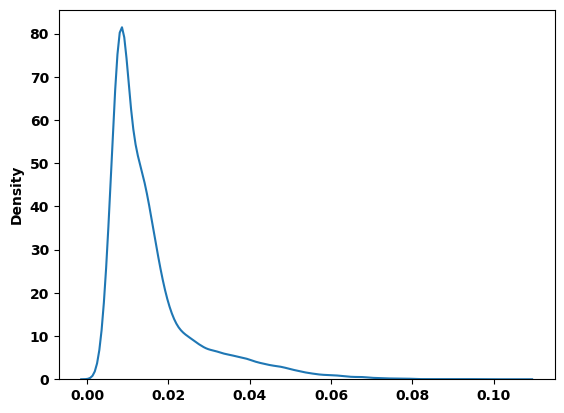

In [9]:
sns.kdeplot(data=mean_ratio_individual)

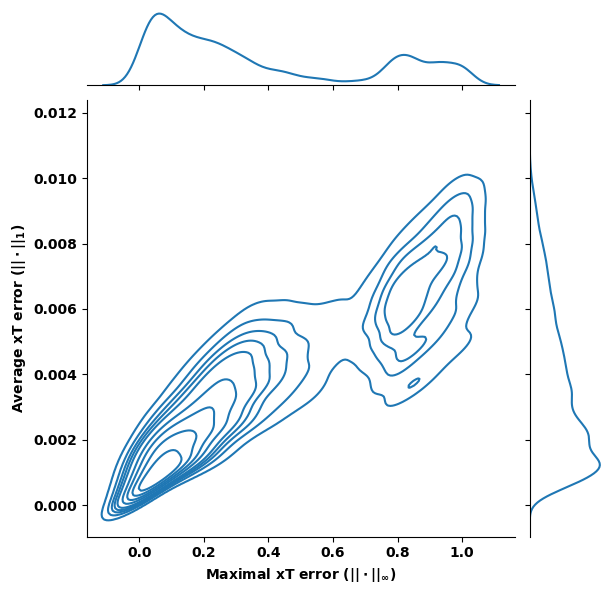

In [8]:
g = sns.jointplot(data=df_errors, 
              x="xT_error_inf_norm", 
              y="xT_error_1_norm",
              kind="kde"
              )
g.set_axis_labels(r"Maximal xT error ($||\cdot||_\infty$)", r"Average xT error ($||\cdot||_1$)")

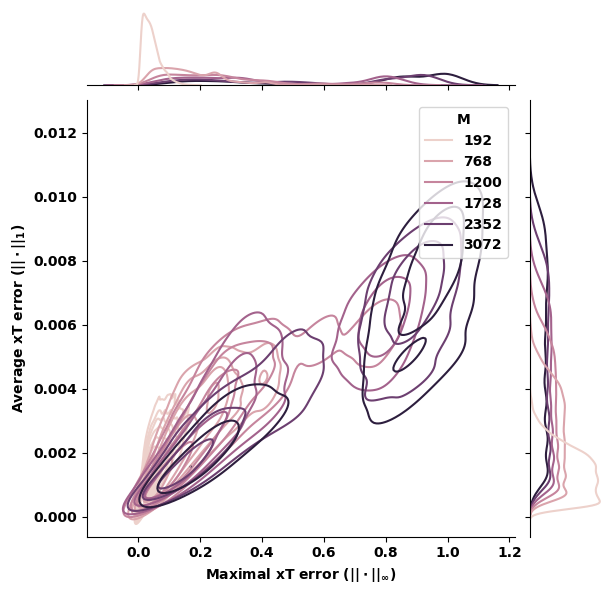

In [9]:
g = sns.jointplot(data=df_errors, 
              x="xT_error_inf_norm", 
              y="xT_error_1_norm",
              kind="kde",
              hue='M'
              )
g.set_axis_labels(r"Maximal xT error ($||\cdot||_\infty$)", r"Average xT error ($||\cdot||_1$)")

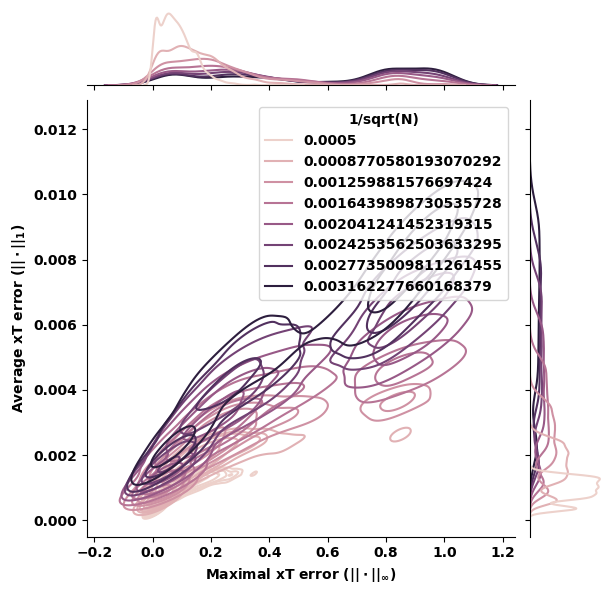

In [ ]:
g = sns.jointplot(data=df_errors, 
              x="xT_error_inf_norm", 
              y="xT_error_1_norm",
              kind="kde",
              hue='1/sqrt(N)'
              )
g.set_axis_labels(r"Maximal xT error ($||\cdot||_\infty$)", r"Average xT error ($||\cdot||_1$)")

# Infinity norm

Text(0.5, 0, 'Maximal xT error ($||\\cdot||_\\infty$)')

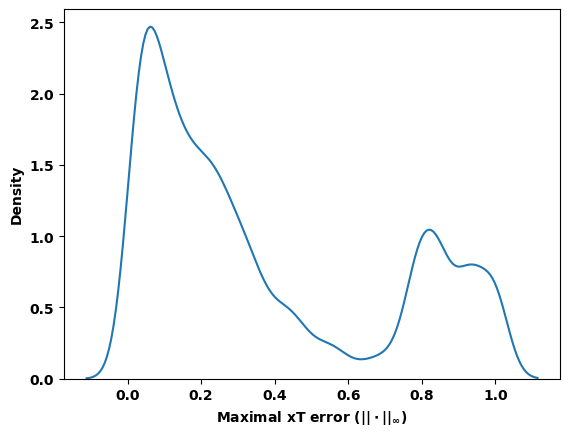

In [ ]:
ax = sns.kdeplot(data=df_errors, x='xT_error_inf_norm')
ax.set_xlabel(r"Maximal xT error ($||\cdot||_\infty$)")

### Inspection of case with error = 1.0

In [ ]:
df_errors[df_errors['xT_error_inf_norm'] == 1.0].head(1)

,n_x,n_y,N,i_bootstrap,random_state,xT_error_1_norm,g_error_1_norm,xG_error_1_norm,prob_shot_error_1_norm,transition_matrix_error_1_norm,...,xT_error_inf_norm,g_error_inf_norm,xG_error_inf_norm,prob_shot_error_inf_norm,transition_matrix_error_inf_norm,transition_matrix_true_inf_norm,transition_matrix_resampled_inf_norm,M,1/sqrt(N),Mlog(M)/sqrt(N)
41169,64,48,1300000,169,6004211,0.002573,0.001988,0.010295,0.003698,0.000586,...,1.0,1.0,1.0,1.0,1.566667,1.0,1.0,3072,0.000877,21.635634


In [10]:
xT_true = xThreat.load_from_pickle('../0-model-storage/xt-full-data-n_x64-n_y48.pickle')
xT_resampled = xThreat.load_from_pickle('../0-model-storage/xt-N1300000-n_x64-n_y48-i_bootstrap169-random_state6004211.pickle')

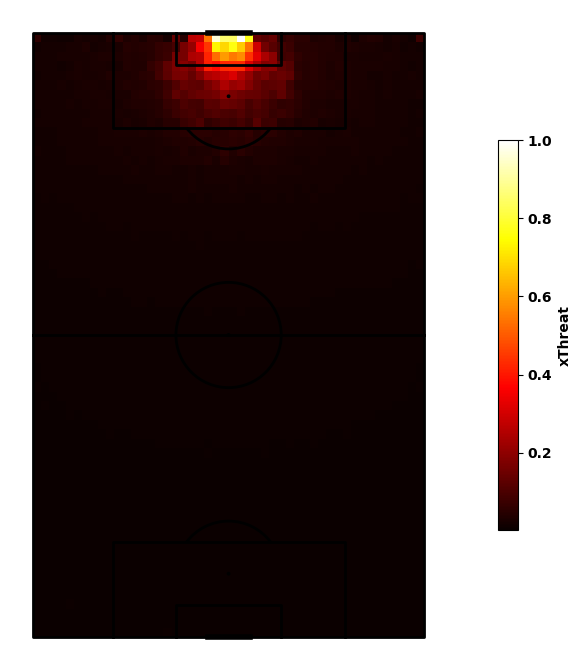

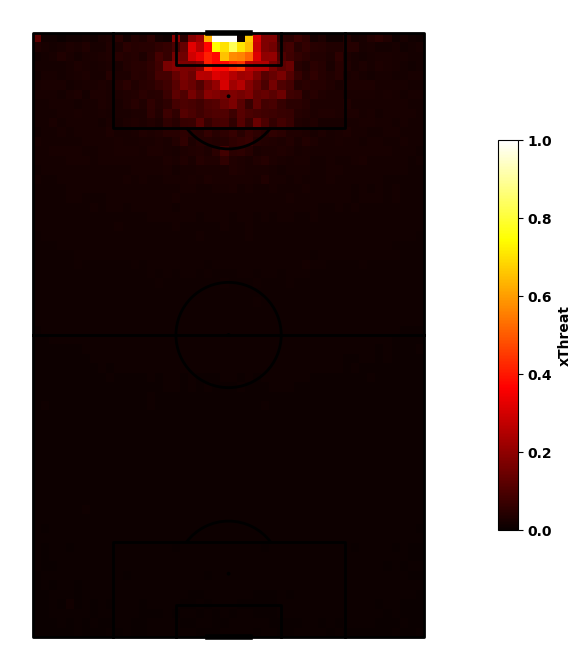

In [11]:
xT_true.plot_xThreat()
xT_resampled.plot_xThreat()

### Going on

Text(0.5, 0, 'Maximal xT error ($||\\cdot||_\\infty$)')

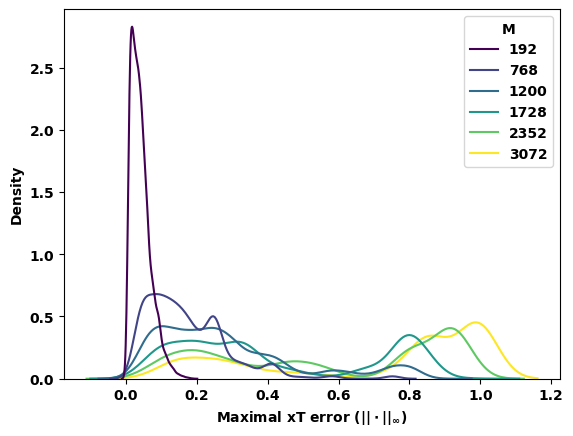

In [10]:
ax = sns.kdeplot(data=df_errors, x='xT_error_inf_norm', hue='M', palette='viridis')
ax.set_xlabel(r"Maximal xT error ($||\cdot||_\infty$)")

Text(0.5, 0, 'Maximal xT error ($||\\cdot||_\\infty$)')

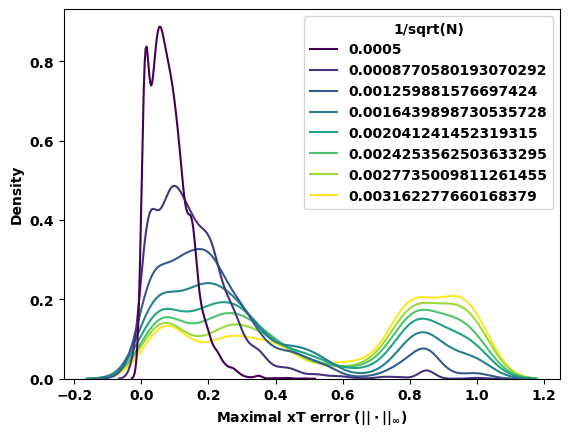

In [11]:
ax = sns.kdeplot(data=df_errors, x='xT_error_inf_norm', hue='1/sqrt(N)', palette='viridis')
ax.set_xlabel(r"Maximal xT error ($||\cdot||_\infty$)")

[(np.float64(0.267004), np.float64(0.004874), np.float64(0.329415), np.float64(1.0)), (np.float64(0.275191), np.float64(0.194905), np.float64(0.496005), np.float64(1.0)), (np.float64(0.212395), np.float64(0.359683), np.float64(0.55171), np.float64(1.0)), (np.float64(0.151918), np.float64(0.500685), np.float64(0.557587), np.float64(1.0)), (np.float64(0.12478), np.float64(0.640461), np.float64(0.527068), np.float64(1.0)), (np.float64(0.311925), np.float64(0.767822), np.float64(0.415586), np.float64(1.0)), (np.float64(0.616293), np.float64(0.852709), np.float64(0.230052), np.float64(1.0)), (np.float64(0.993248), np.float64(0.906157), np.float64(0.143936), np.float64(1.0))]


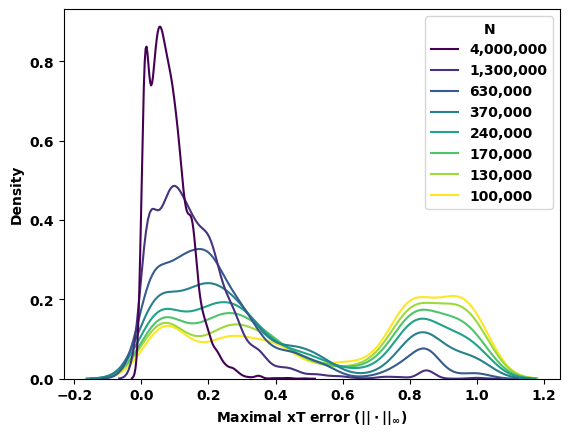

In [12]:
cmap = 'viridis'

ax = sns.kdeplot(data=df_errors, x='xT_error_inf_norm', hue='1/sqrt(N)', palette=cmap)

# Get the unique hue values ('1/sqrt(N)')
hue_levels = np.unique(df_errors['1/sqrt(N)'])
rounded_hue_levels = [f"{int(1/level**2):,}" for level in hue_levels]

# Create a color palette based on the hue values
cmap = matplotlib.colormaps[cmap]
palette = [cmap( (hue_level-hue_levels.min())/(hue_levels.max()-hue_levels.min()) ) for hue_level in hue_levels]
print(cmap)
# Create custom legend handles: we need to map each color to the corresponding hue value
handles = [matplotlib.lines.Line2D([0], [0], color=palette[i]) for i in range(len(hue_levels))]

# Set the legend with the correct rounded labels
ax.legend(handles, rounded_hue_levels, title=r"$N$")
print(palette)
# Set the x-axis label
ax.set_xlabel(r"Maximal xT error ($||\cdot||_\infty$)")

plt.show()

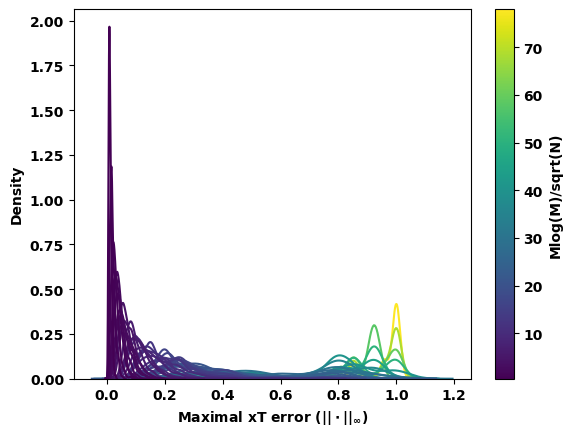

In [13]:
fig, ax = plt.subplots()
norm = plt.Normalize(df_errors['Mlog(M)/sqrt(N)'].min(), df_errors['Mlog(M)/sqrt(N)'].max())
sm = plt.cm.ScalarMappable(cmap='viridis', norm=norm)
sm.set_array([])

sns.kdeplot(
    data=df_errors, 
    x='xT_error_inf_norm', 
    hue='Mlog(M)/sqrt(N)', 
    palette='viridis',
    hue_norm=norm,
    ax=ax
)

# Remove the legend
ax.get_legend().remove()
ax.set_xlabel(r"Maximal xT error ($||\cdot||_\infty$)")

# Add a color bar
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Mlog(M)/sqrt(N)')

plt.show()

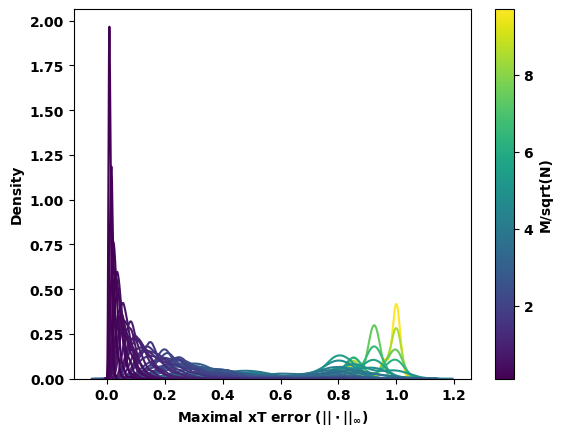

In [15]:
fig, ax = plt.subplots()
df_errors['M/sqrt(N)'] = df_errors['M']/np.sqrt(df_errors['N'])
norm = plt.Normalize(df_errors['M/sqrt(N)'].min(), df_errors['M/sqrt(N)'].max())
sm = plt.cm.ScalarMappable(cmap='viridis', norm=norm)
sm.set_array([])

sns.kdeplot(
    data=df_errors, 
    x='xT_error_inf_norm', 
    hue='M/sqrt(N)', 
    palette='viridis',
    hue_norm=norm,
    ax=ax
)

# Remove the legend
ax.get_legend().remove()
ax.set_xlabel(r"Maximal xT error ($||\cdot||_\infty$)")

# Add a color bar
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('M/sqrt(N)')

plt.show()

In [ ]:
# Define the plot
g = sns.PairGrid(df_errors[['xT_error_inf_norm', 'transition_matrix_error_inf_norm', 
                            'g_error_inf_norm', 'xG_error_inf_norm', 'prob_shot_error_inf_norm']])

# Map different plots to different sections of the grid
def corrfunc(x, y, **kwargs):
    r = np.corrcoef(x, y)[0, 1]
    ax = plt.gca()
    ax.annotate(f'r = {r:.2f}', xy=(0.5, 0.5), xycoords=ax.transAxes, 
                ha="center", va="center", fontsize=12, fontweight="bold")

g.map_upper(corrfunc)
g.map_lower(sns.kdeplot, fill=True)
g.map_diag(sns.histplot)

# Rename axis labels
new_labels = {
    'xT_error_inf_norm': 'Maximal xT Error',
    'transition_matrix_error_inf_norm': 'Maximal Transition Matrix Error',
    'g_error_inf_norm': 'Maximal g Error',
    'xG_error_inf_norm': 'Maximal xG Error',
    'prob_shot_error_inf_norm': 'Maximal Probability Shot Error'
}

# Update axis labels
for ax in g.axes.flatten():
    if ax is not None:  # Some may be empty
        xlabel = ax.get_xlabel()
        ylabel = ax.get_ylabel()
        if xlabel in new_labels:
            ax.set_xlabel(new_labels[xlabel])
        if ylabel in new_labels:
            ax.set_ylabel(new_labels[ylabel])

plt.show()

In [ ]:
g = sns.PairGrid(df_errors[['xT_error_inf_norm', 'transition_matrix_error_inf_norm', 'g_error_inf_norm', 'xG_error_inf_norm', 'prob_shot_error_inf_norm']])
g.map_upper(sns.histplot)
g.map_lower(sns.kdeplot, fill=True)
g.map_diag(sns.regplot, lowess=True)

: 

: 

It seems like the error in the g-vector has the strongest relation with the actual xT error with respect to the infinity norm. It is interesting to note that the g value is the xG value multiplied with the prob_shot value. <br>
At the same time, it looks like the xG error has generally very large errors. This is well-known behaviour from practice: there are often some spots at the pitch where almost no shots are taken. If the sample contains one shot where it has large values, this will be visible in a very high xG value. Still it is interesting to investigate this behaviour. This is done in the file xG_error_inspection.ipynb.

# 1-norm

Text(0.5, 0, 'Average xT error ($||\\cdot||_1$)')

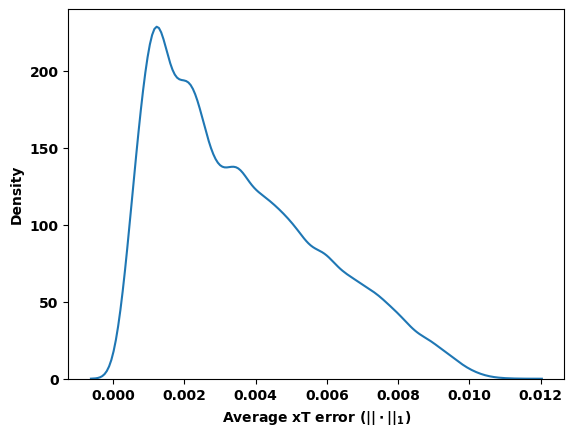

In [ ]:
ax = sns.kdeplot(data=df_errors, x='xT_error_1_norm')
ax.set_xlabel(r"Average xT error ($||\cdot||_1$)")

Text(0.5, 0, 'Average xT error ($||\\cdot||_1$)')

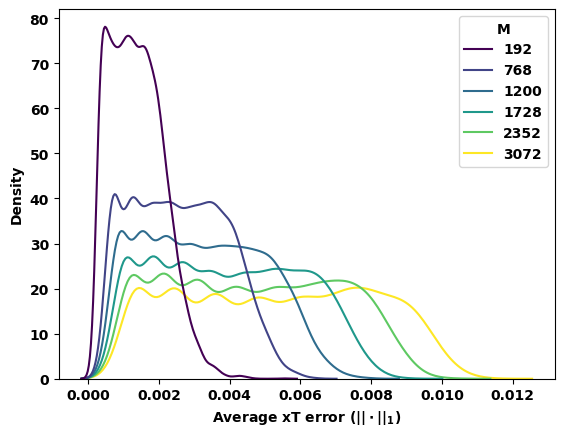

In [ ]:
ax = sns.kdeplot(data=df_errors, x='xT_error_1_norm', hue='M', palette='viridis')
ax.set_xlabel(r"Average xT error ($||\cdot||_1$)")

[(np.float64(0.267004), np.float64(0.004874), np.float64(0.329415), np.float64(1.0)), (np.float64(0.275191), np.float64(0.194905), np.float64(0.496005), np.float64(1.0)), (np.float64(0.212395), np.float64(0.359683), np.float64(0.55171), np.float64(1.0)), (np.float64(0.151918), np.float64(0.500685), np.float64(0.557587), np.float64(1.0)), (np.float64(0.12478), np.float64(0.640461), np.float64(0.527068), np.float64(1.0)), (np.float64(0.311925), np.float64(0.767822), np.float64(0.415586), np.float64(1.0)), (np.float64(0.616293), np.float64(0.852709), np.float64(0.230052), np.float64(1.0)), (np.float64(0.993248), np.float64(0.906157), np.float64(0.143936), np.float64(1.0))]


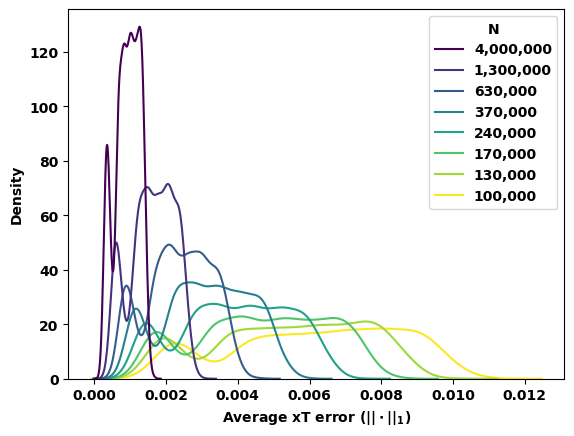

In [ ]:
cmap = 'viridis'

ax = sns.kdeplot(data=df_errors, x='xT_error_1_norm', hue='1/sqrt(N)', palette=cmap)

# Get the unique hue values ('1/sqrt(N)')
hue_levels = np.unique(df_errors['1/sqrt(N)'])
rounded_hue_levels = [f"{int(1/level**2):,}" for level in hue_levels]

# Create a color palette based on the hue values
cmap = matplotlib.colormaps[cmap]
palette = [cmap( (hue_level-hue_levels.min())/(hue_levels.max()-hue_levels.min()) ) for hue_level in hue_levels]
print(cmap)
# Create custom legend handles: we need to map each color to the corresponding hue value
handles = [matplotlib.lines.Line2D([0], [0], color=palette[i]) for i in range(len(hue_levels))]

# Set the legend with the correct rounded labels
ax.legend(handles, rounded_hue_levels, title=r"$N$")
print(palette)
# Set the x-axis label
ax.set_xlabel(r"Average xT error ($||\cdot||_1$)")

plt.show()

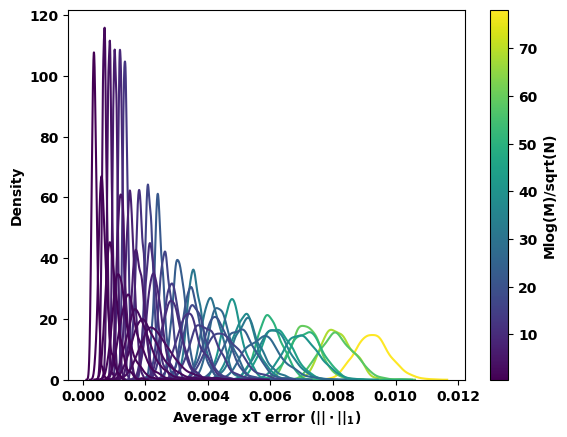

In [12]:
fig, ax = plt.subplots()
norm = plt.Normalize(df_errors['Mlog(M)/sqrt(N)'].min(), df_errors['Mlog(M)/sqrt(N)'].max())
sm = plt.cm.ScalarMappable(cmap='viridis', norm=norm)
sm.set_array([])

sns.kdeplot(
    data=df_errors, 
    x='xT_error_1_norm', 
    hue='Mlog(M)/sqrt(N)', 
    palette='viridis',
    hue_norm=norm,
    ax=ax
)

# Remove the legend
ax.get_legend().remove()

# Add a color bar
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Mlog(M)/sqrt(N)')

# Set the x-axis label
ax.set_xlabel(r"Average xT error ($||\cdot||_1$)")

plt.show()

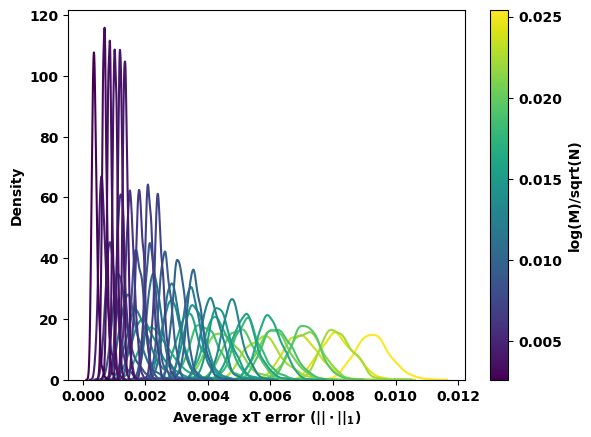

In [13]:
fig, ax = plt.subplots()
df_errors['log(M)/sqrt(N)'] = np.log(df_errors['M'])/np.sqrt(df_errors['N'])
norm = plt.Normalize(df_errors['log(M)/sqrt(N)'].min(), df_errors['log(M)/sqrt(N)'].max())
sm = plt.cm.ScalarMappable(cmap='viridis', norm=norm)
sm.set_array([])

sns.kdeplot(
    data=df_errors, 
    x='xT_error_1_norm', 
    hue='log(M)/sqrt(N)', 
    palette='viridis',
    hue_norm=norm,
    ax=ax
)

# Remove the legend
ax.get_legend().remove()

# Add a color bar
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('log(M)/sqrt(N)')

# Set the x-axis label
ax.set_xlabel(r"Average xT error ($||\cdot||_1$)")

plt.show()

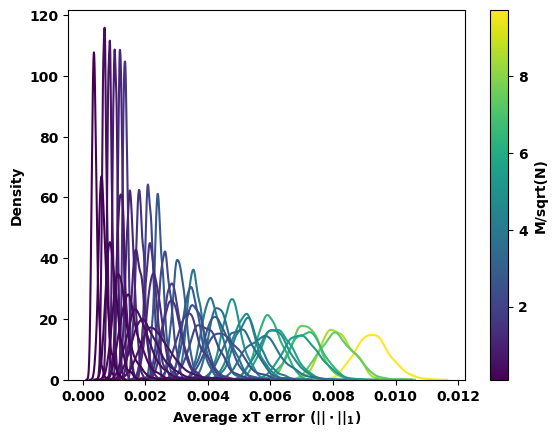

In [14]:
fig, ax = plt.subplots()
df_errors['M/sqrt(N)'] = df_errors['M']/np.sqrt(df_errors['N'])
norm = plt.Normalize(df_errors['M/sqrt(N)'].min(), df_errors['M/sqrt(N)'].max())
sm = plt.cm.ScalarMappable(cmap='viridis', norm=norm)
sm.set_array([])

sns.kdeplot(
    data=df_errors, 
    x='xT_error_1_norm', 
    hue='M/sqrt(N)', 
    palette='viridis',
    hue_norm=norm,
    ax=ax
)

# Remove the legend
ax.get_legend().remove()

# Add a color bar
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('M/sqrt(N)')

# Set the x-axis label
ax.set_xlabel(r"Average xT error ($||\cdot||_1$)")

plt.show()

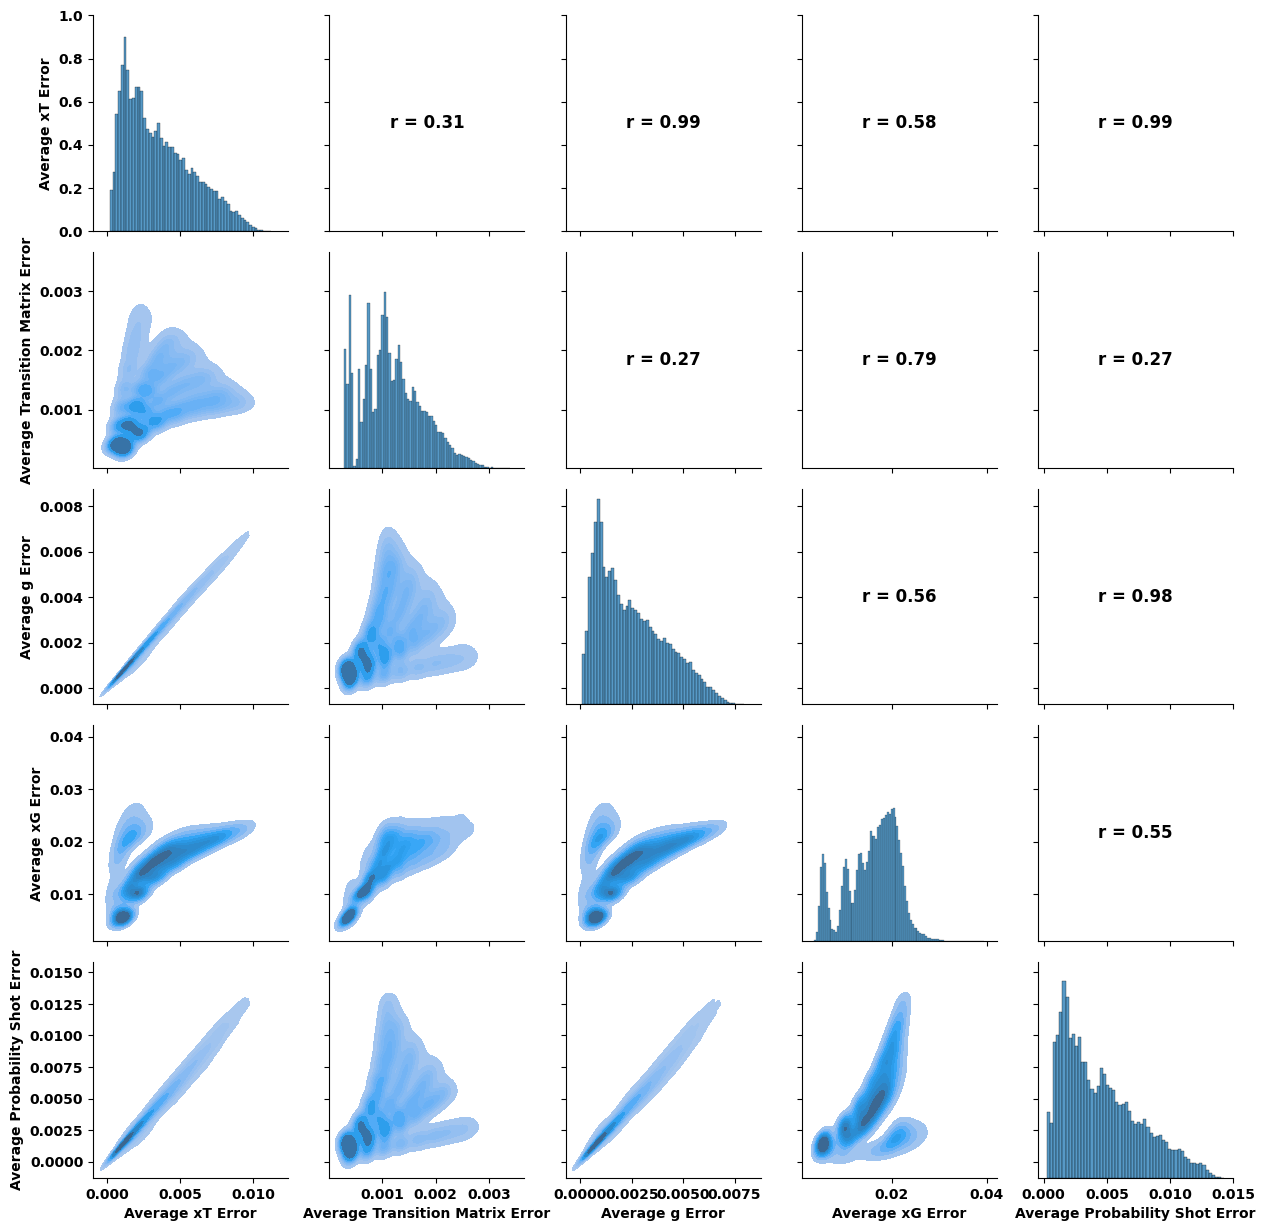

In [32]:
# Define the plot
g = sns.PairGrid(df_errors[['xT_error_1_norm', 'transition_matrix_error_1_norm', 
                            'g_error_1_norm', 'xG_error_1_norm', 'prob_shot_error_1_norm']])

# Map different plots to different sections of the grid
def corrfunc(x, y, **kwargs):
    r = np.corrcoef(x, y)[0, 1]
    ax = plt.gca()
    ax.annotate(f'r = {r:.2f}', xy=(0.5, 0.5), xycoords=ax.transAxes, 
                ha="center", va="center", fontsize=12, fontweight="bold")

g.map_upper(corrfunc)
g.map_lower(sns.kdeplot, fill=True)
g.map_diag(sns.histplot)

# Rename axis labels
new_labels = {
    'xT_error_1_norm': 'Average xT Error',
    'transition_matrix_error_1_norm': 'Average Transition Matrix Error',
    'g_error_1_norm': 'Average g Error',
    'xG_error_1_norm': 'Average xG Error',
    'prob_shot_error_1_norm': 'Average Probability Shot Error'
}

# Update axis labels
for ax in g.axes.flatten():
    if ax is not None:  # Some may be empty
        xlabel = ax.get_xlabel()
        ylabel = ax.get_ylabel()
        if xlabel in new_labels:
            ax.set_xlabel(new_labels[xlabel])
        if ylabel in new_labels:
            ax.set_ylabel(new_labels[ylabel])

plt.show()

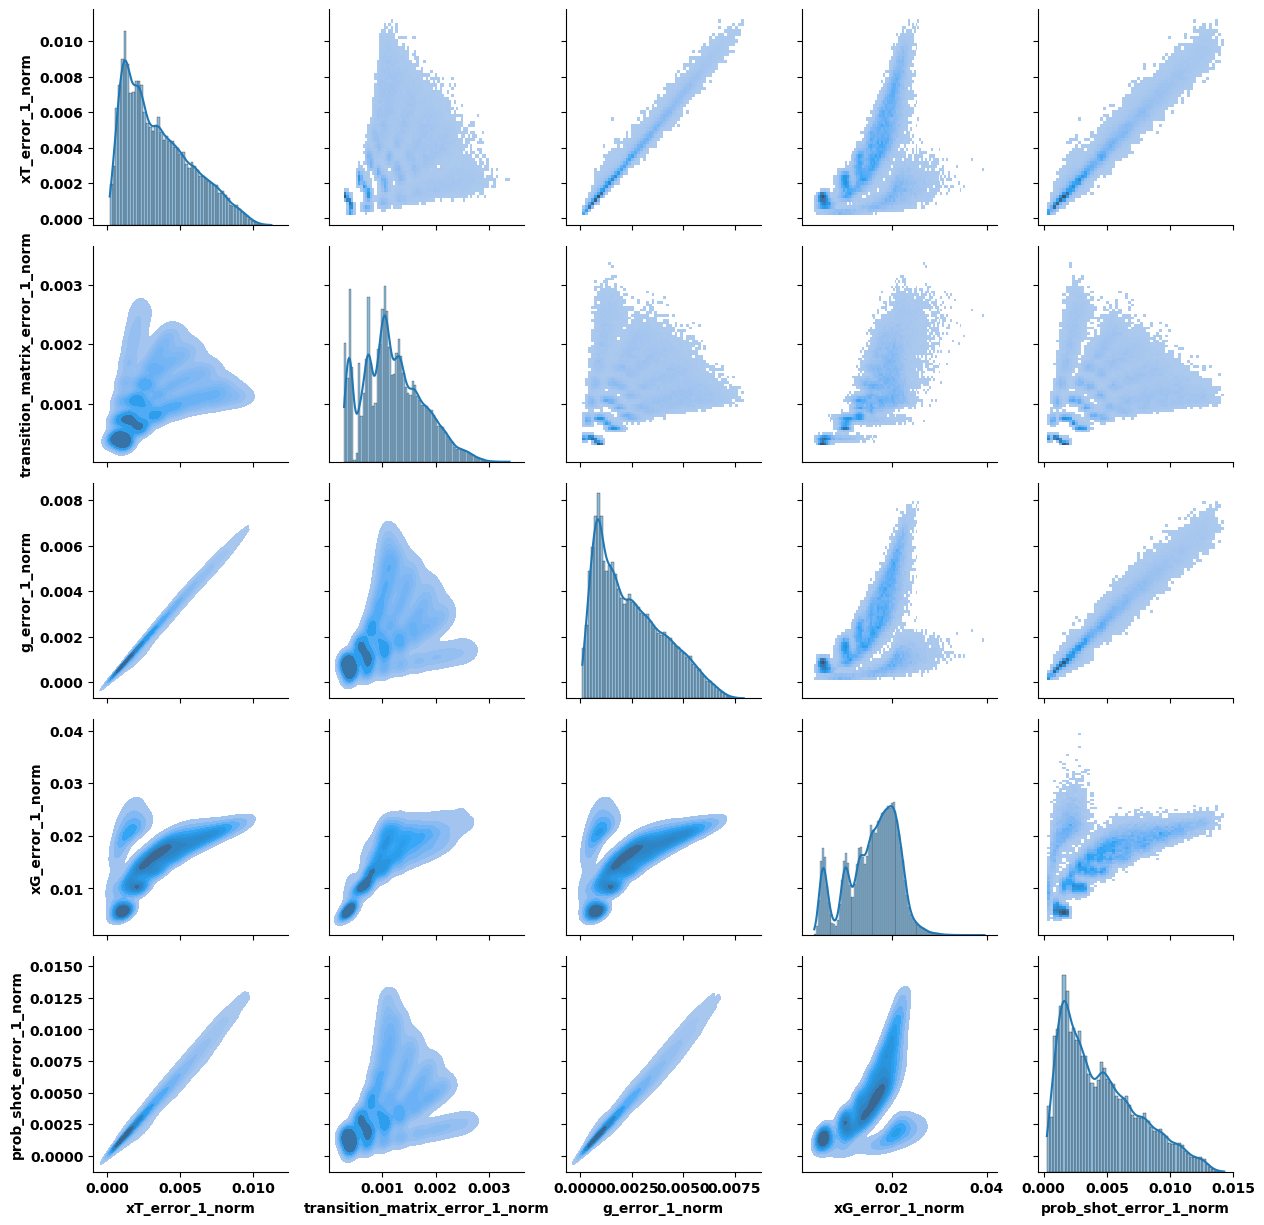

In [20]:
g = sns.PairGrid(df_errors[['xT_error_1_norm', 'transition_matrix_error_1_norm', 'g_error_1_norm', 'xG_error_1_norm', 'prob_shot_error_1_norm']])
g.map_upper(sns.histplot)
g.map_lower(sns.kdeplot, fill=True)
g.map_diag(sns.histplot, kde=True)